In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import VotingClassifier,StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
data = load_breast_cancer()
X_clf = data.data
y_clf = data.target

In [61]:
print("Class Distribution:")
print(pd.Series(y_clf).value_counts())

Class Distribution:
1    357
0    212
Name: count, dtype: int64


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

In [63]:
lr = LogisticRegression()
svc = SVC()
dtc = DecisionTreeClassifier(max_depth=3)

# Voting 

In [64]:
lr_scaled = make_pipeline(StandardScaler(), LogisticRegression())
svc_scaled = make_pipeline(StandardScaler(), SVC(probability=True))
dtc = DecisionTreeClassifier(max_depth=3)


voting_clf = VotingClassifier(
    estimators=[("lr", lr_scaled), ("svc", svc_scaled), ("dtc", dtc)],
    voting='soft' # 'soft' usually performs better for imbalanced Kaggle-style data
)


voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test) 

In [65]:
print("--- Voting Classifier Results ---")
print(classification_report(y_test, y_pred))

--- Voting Classifier Results ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



# Stacking

In [66]:
stacking_clf = StackingClassifier(
    estimators=[("lr", lr_scaled), ("svc", svc_scaled), ("dtc", dtc)],
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

print("--- Stacking Classifier Results ---")
print(classification_report(y_test, y_pred_stack))

--- Stacking Classifier Results ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



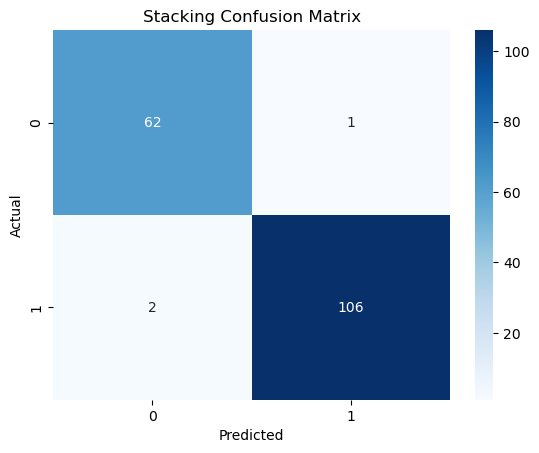

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stacking Confusion Matrix')
plt.show()

In [68]:
# Get probabilities instead of just 0 or 1
y_probs = stacking_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)

print(f"Stacking AUC-ROC Score: {auc:.4f}")

Stacking AUC-ROC Score: 0.9975
